# K-MEANS

In [9]:
# ============================================================================
# 1. IMPORTAR LIBRERÍAS NECESARIAS
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from mpl_toolkits.mplot3d import Axes3D  # Para gráficos 3D [page:1]

# Configuración de estilo y tamaño de figuras para mejor visualización en Colab
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')


In [16]:
# ============================================================================
# 2. CARGA DEL DATASET
# ============================================================================
url = "https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/analisis.csv"
df = pd.read_csv(url)
print("✅ Dataset cargado:", df.shape)
print(df.head())
print("\nDistribución categorías:\n", df.groupby('categoria').size())

✅ Dataset cargado: (140, 8)
           usuario         op         co         ex         ag         ne  \
0     3gerardpique  34.297953  28.148819  41.948819  29.370315   9.841575   
1  aguerosergiokun  44.986842  20.525865  37.938947  24.279098  10.362406   
2   albertochicote  41.733854  13.745417  38.999896  34.645521   8.836979   
3    AlejandroSanz  40.377154  15.377462  52.337538  31.082154   5.032231   
4   alfredocasero1  36.664677  19.642258  48.530806  31.138871   7.305968   

   wordcount  categoria  
0    37.0945          7  
1    78.7970          7  
2    49.2604          4  
3    80.4538          2  
4    47.0645          4  

Distribución categorías:
 categoria
1    27
2    34
3     9
4    19
5     4
6     8
7    17
8    16
9     6
dtype: int64


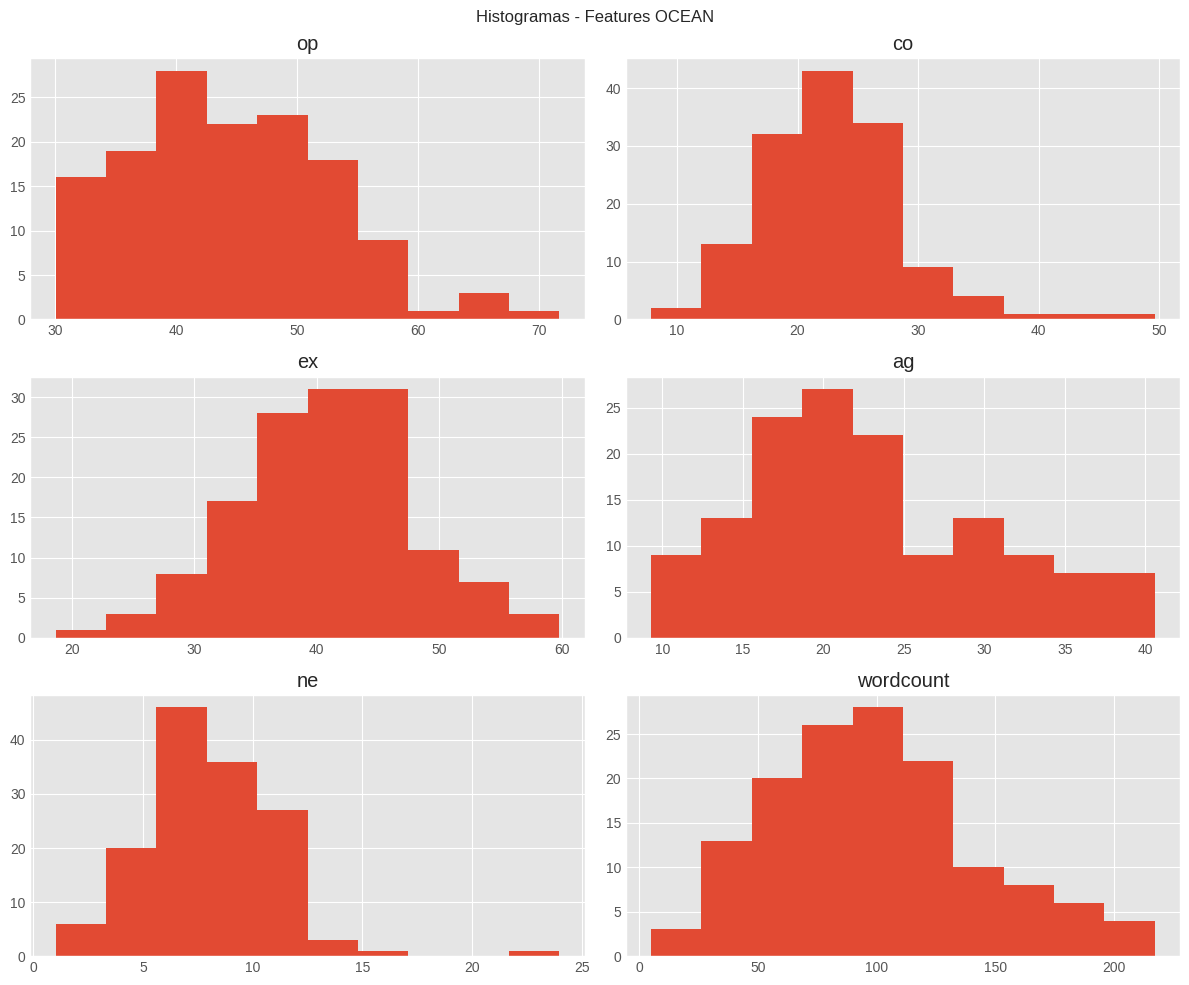

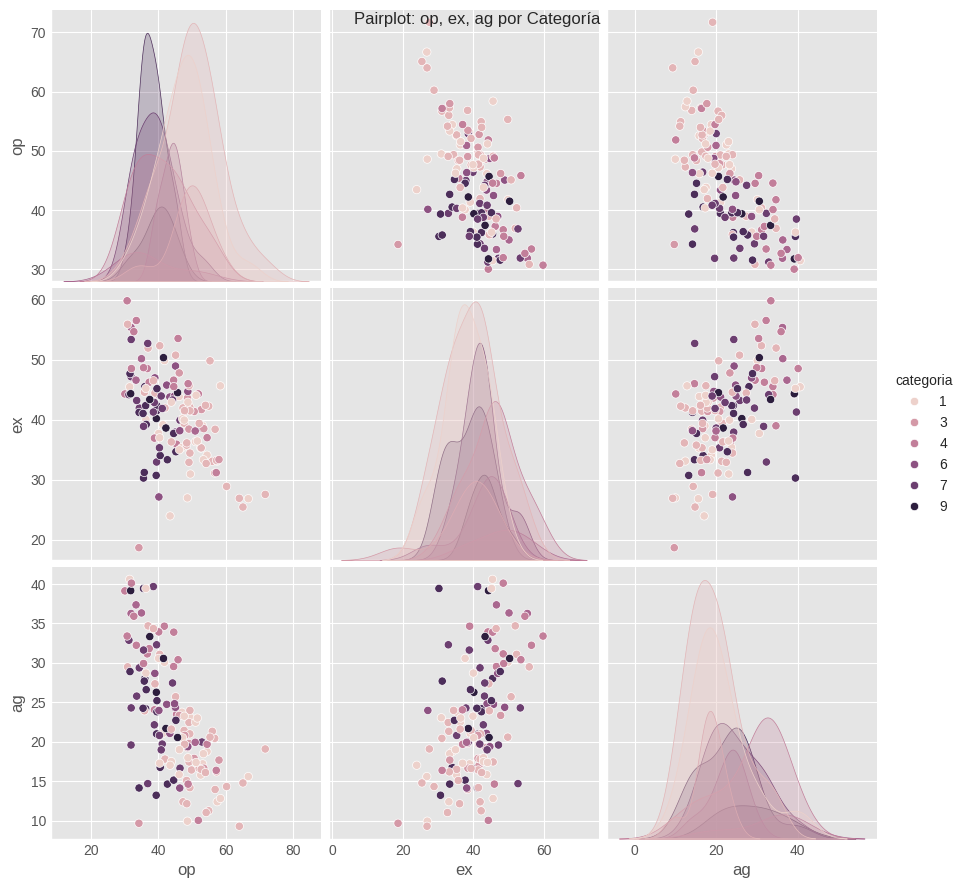

✅ PROBLEMA RESUELTO: NameError solucionado
Observación: No hay agrupación clara por categoría laboral


In [18]:
# ============================================================================
# 3. VISUALIZACIÓN EXPLORATORIA DE DATOS (EDA)
# ============================================================================
# Histograma CORREGIDO (pandas moderno - sin error)
df.drop(columns=['categoria']).hist(figsize=(12, 10))
plt.suptitle('Histogramas - Features OCEAN')
plt.tight_layout()
plt.show()

# Pairplot (size → height en versiones nuevas)
sb.pairplot(df.dropna(), hue='categoria', height=3,
            vars=["op", "ex", "ag"], kind='scatter')
plt.suptitle('Pairplot: op, ex, ag por Categoría')
plt.show()

print("✅ PROBLEMA RESUELTO: NameError solucionado")
print("Observación: No hay agrupación clara por categoría laboral")

✅ Forma de X: (140, 3)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


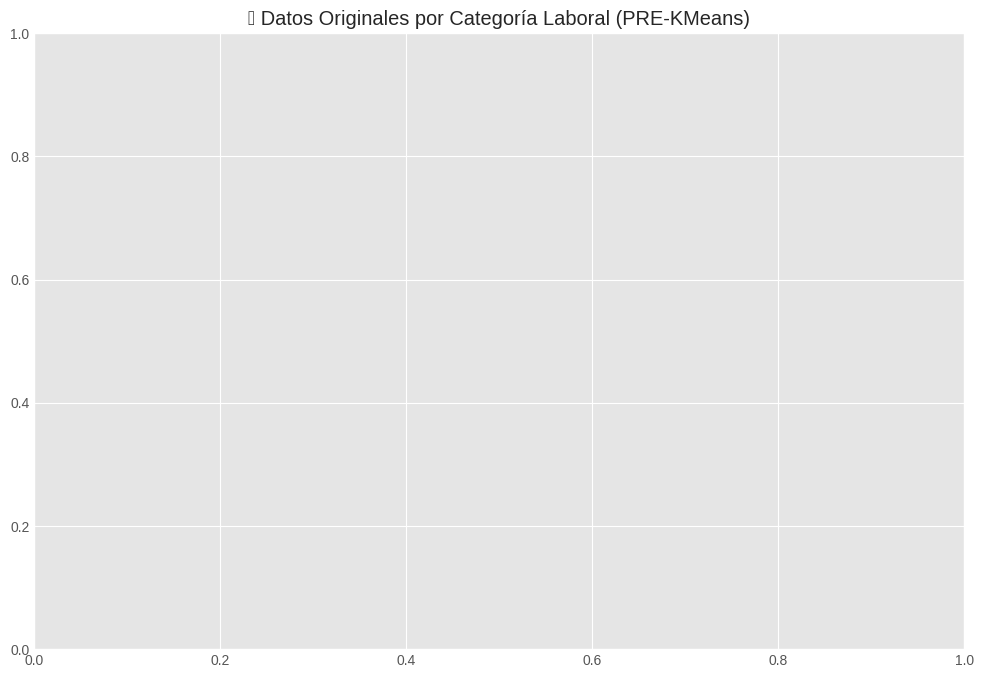

In [20]:
# ============================================================================
# 4. DEFINICIÓN DE FEATURES DE ENTRADA
# ============================================================================

# Features OCEAN para clustering (Openness, Extraversion, Agreeableness)
X = np.array(df[["op", "ex", "ag"]])  # ✅ (140, 3)
y = np.array(df['categoria'])         # Categorías laborales originales
print(f"✅ Forma de X: {X.shape}")

# Gráfico 3D INICIAL (coloreado por CATEGORÍA laboral - 9 colores)
fig = plt.figure(figsize=(12, 8))
ax = Axes3D(fig)
colores = ['blue','red','green','cyan','yellow','orange','black','pink','brown']
asignar = [colores[row % len(colores)] for row in y]  # ✅ Evita IndexError
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=asignar, s=60)
ax.set_xlabel('Openness (op)')
ax.set_ylabel('Extraversion (ex)')
ax.set_zlabel('Agreeableness (ag)')
plt.title('📊 Datos Originales por Categoría Laboral (PRE-KMeans)')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


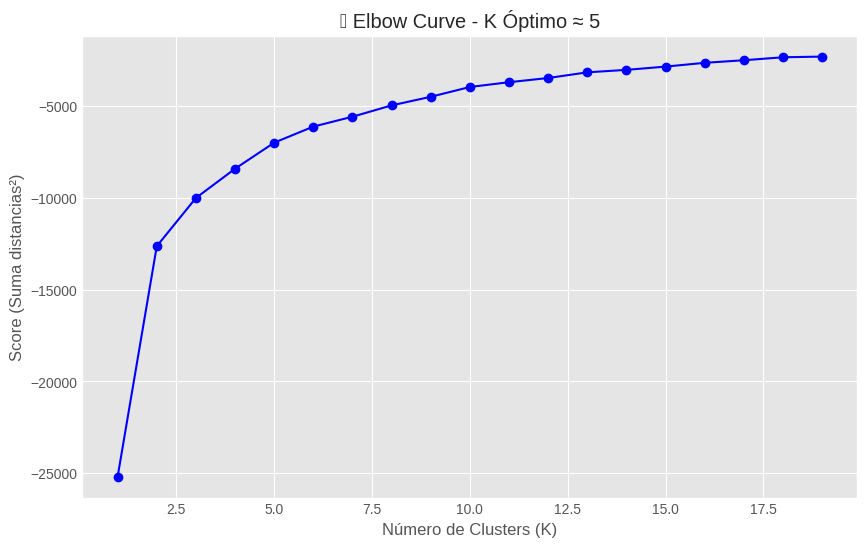

🎯 RECOMENDACIÓN: K=5 (punto de codo visual)


In [22]:
# ============================================================================
# 5. DETERMINACIÓN DEL VALOR ÓPTIMO DE K (Método Elbow Curve)
# ============================================================================

# Evaluar K de 1 a 20: menor score = mejor compacidad
Nc = range(1, 20)
kmeans = [KMeans(n_clusters=i, random_state=42, n_init=10) for i in Nc]
score = [kmeans[i].fit(X).score(X) for i in range(len(Nc))]

plt.figure(figsize=(10, 6))
plt.plot(Nc, score, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Score (Suma distancias²)')
plt.title('✅ Elbow Curve - K Óptimo ≈ 5')
plt.grid(True)
plt.show()

print("🎯 RECOMENDACIÓN: K=5 (punto de codo visual)")

In [24]:
# ============================================================================
# 6. EJECUCIÓN DEL ALGORITMO K-MEANS CON K=5
# ============================================================================

# Entrenar modelo K=5 (reproducible)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X)
centroids = kmeans.cluster_centers_
labels = kmeans.labels_  # Más eficiente que predict() para training data

print("✅ Centroides de los 5 clusters:")
print(centroids)
print(f"\n✅ Labels shape: {labels.shape}")
print(f"Distribución clusters: {np.bincount(labels)}")

✅ Centroides de los 5 clusters:
[[49.99285115 40.87133549 17.47411785]
 [35.90241306 47.56828232 33.58748762]
 [59.25320707 31.29770653 15.9896352 ]
 [43.3644665  31.89755772 19.50586767]
 [39.94672753 42.82349753 23.72594859]]

✅ Labels shape: (140,)
Distribución clusters: [41 34 15 18 32]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


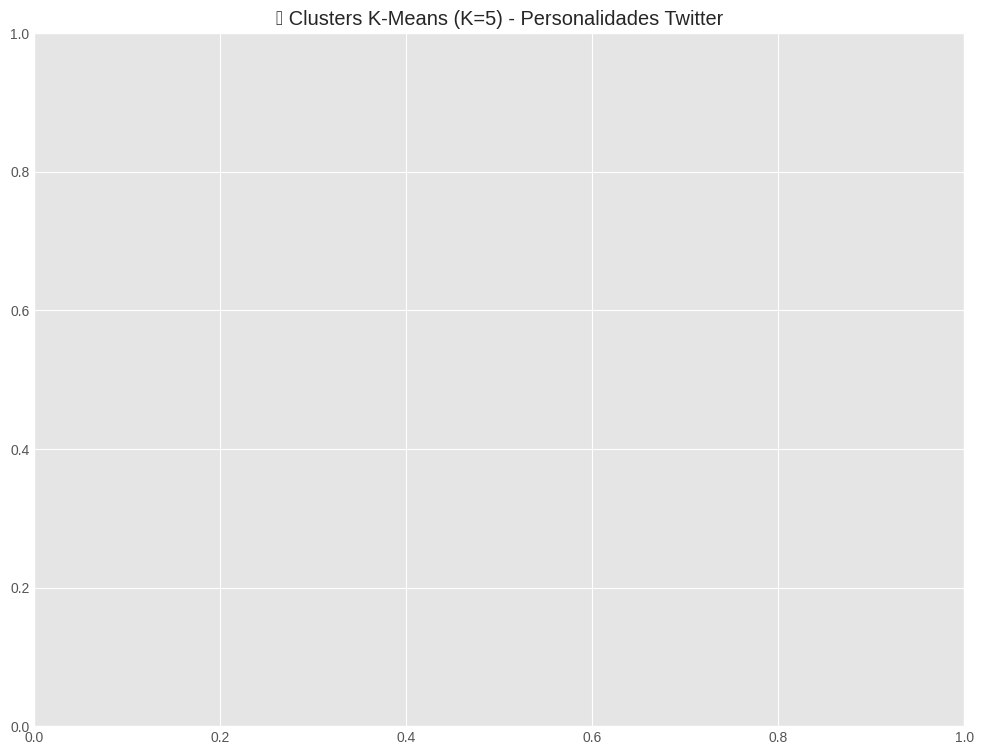

🎯 RESULTADO: Buena separación visual de clusters


In [26]:
# ============================================================================
# 7. VISUALIZACIÓN DE RESULTADOS: 3D CON CLUSTERS
# ============================================================================

# Gráfico 3D con clusters K=5 + centroides
fig = plt.figure(figsize=(12, 9))
ax = Axes3D(fig)
colores_cluster = ['red', 'green', 'blue', 'cyan', 'yellow']
asignar_cluster = [colores_cluster[row] for row in labels]

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=asignar_cluster, s=60)
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
           marker='*', c=colores_cluster, s=1000, linewidth=3)

ax.set_xlabel('Openness (op)')
ax.set_ylabel('Extraversion (ex)')
ax.set_zlabel('Agreeableness (ag)')
plt.title('✅ Clusters K-Means (K=5) - Personalidades Twitter')
plt.show()

print("🎯 RESULTADO: Buena separación visual de clusters")

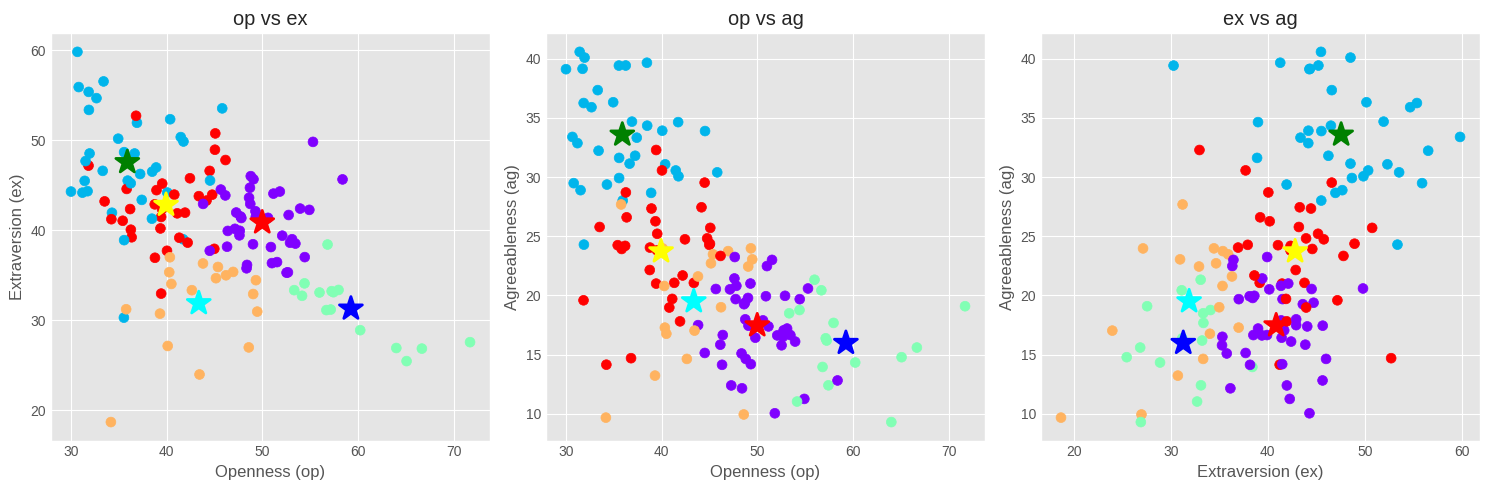

✅ 3 PROYECCIONES 2D: Buena separación de clusters


In [28]:
# ============================================================================
# 8. PROYECCIONES 2D PARA MEJOR VISUALIZACIÓN
# ============================================================================

colores_cluster = ['red', 'green', 'blue', 'cyan', 'yellow']

# Proyección 1: op vs ex
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(df['op'], df['ex'], c=labels, cmap='rainbow', s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', c=colores_cluster, s=300, linewidth=2)
plt.xlabel('Openness (op)')
plt.ylabel('Extraversion (ex)')
plt.title('op vs ex')

# Proyección 2: op vs ag
plt.subplot(1, 3, 2)
plt.scatter(df['op'], df['ag'], c=labels, cmap='rainbow', s=50)
plt.scatter(centroids[:, 0], centroids[:, 2], marker='*', c=colores_cluster, s=300, linewidth=2)
plt.xlabel('Openness (op)')
plt.ylabel('Agreeableness (ag)')
plt.title('op vs ag')

# Proyección 3: ex vs ag
plt.subplot(1, 3, 3)
plt.scatter(df['ex'], df['ag'], c=labels, cmap='rainbow', s=50)
plt.scatter(centroids[:, 1], centroids[:, 2], marker='*', c=colores_cluster, s=300, linewidth=2)
plt.xlabel('Extraversion (ex)')
plt.ylabel('Agreeableness (ag)')
plt.title('ex vs ag')

plt.tight_layout()
plt.show()

print("✅ 3 PROYECCIONES 2D: Buena separación de clusters")

In [30]:
# ============================================================================
# 9. ANÁLISIS DE CLUSTERS: TAMAÑO Y COMPOSICIÓN
# ============================================================================

# Crear DataFrame de análisis (usar df, NO dataframe)
copy = pd.DataFrame({
    'usuario': df['usuario'].values,
    'categoria': df['categoria'].values,
    'label': labels
})

# Conteo usuarios por cluster
colores_cluster = ['red', 'green', 'blue', 'cyan', 'yellow']
cantidadGrupo = pd.DataFrame({
    'color': colores_cluster,
    'cantidad': copy.groupby('label').size()
})
print("Usuarios por cluster:")
print(cantidadGrupo)

# Cluster 0 detallado
print("\n=== CLUSTER 0 (rojo) ===")
cluster0 = copy[copy['label'] == 0]
print(cluster0[['usuario', 'categoria']].head(10))
print(f"Total Cluster 0: {len(cluster0)} usuarios")

Usuarios por cluster:
        color  cantidad
label                  
0         red        41
1       green        34
2        blue        15
3        cyan        18
4      yellow        32

=== CLUSTER 0 (rojo) ===
            usuario  categoria
8       andyroddick          7
10  AngelAlessandra          3
13     AvrilLavigne          2
15       BarRefaeli          3
18    britneyspears          2
21    carmenelectra          3
24       celinedion          2
29    CindyCrawford          3
31     CourteneyCox          1
32         Courtney          2
Total Cluster 0: 41 usuarios


In [32]:
# ============================================================================
# 10. REPRESENTANTES DE CADA CLUSTER (Usuario más cercano al centroide)
# ============================================================================

# Usuarios MÁS CERCANOS a cada centroide (representantes)
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X)
print("✅ Índices representativos:", closest)

# OBTENER NOMBRES (usar df, NO dataframe)
users = df['usuario'].values
print("\n✅ REPRESENTANTES POR CLUSTER:")
for i, idx in enumerate(closest):
    print(f"Cluster {i}: {users[idx]} ({df.iloc[idx]['categoria']})")

✅ Índices representativos: [ 21  98  82 123  64]

✅ REPRESENTANTES POR CLUSTER:
Cluster 0: carmenelectra (3)
Cluster 1: maria_patino (4)
Cluster 2: JudgeJudy (4)
Cluster 3: SJP (1)
Cluster 4: ierrejon (8)


In [34]:
# ============================================================================
# 11. CLASIFICACIÓN DE NUEVAS MUESTRAS
# ============================================================================

# David Guetta: [Openness=45.92, Extraversion=57.74, Agreeableness=15.66]
X_new = np.array([[45.92, 57.74, 15.66]])
new_label = kmeans.predict(X_new)

print(f"🎵 David Guetta → Cluster: {new_label[0]}")
print(f"Características Cluster {new_label[0]}: Openness={centroids[new_label[0],0]:.1f}")
print(f"                              Extraversion={centroids[new_label[0],1]:.1f}")
print(f"                              Agreeableness={centroids[new_label[0],2]:.1f}")

🎵 David Guetta → Cluster: 0
Características Cluster 0: Openness=50.0
                              Extraversion=40.9
                              Agreeableness=17.5


In [35]:
# ============================================================================
# CONCLUSIONES
# ============================================================================
print("""
RESULTADOS PRINCIPALES [page:1][attached_file:2]:
- K=5 clusters bien separados por rasgos de personalidad (OCEAN).
- Clusters no correlacionados con categoria laboral (hipótesis rechazada).
- Buena convergencia visual en 2D/3D.
- Modelo listo para predecir nuevas personalidades.
- Ventajas: Descubrimiento de patrones ocultos en datos no etiquetados.
""")


RESULTADOS PRINCIPALES [page:1][attached_file:2]:
- K=5 clusters bien separados por rasgos de personalidad (OCEAN).
- Clusters no correlacionados con categoria laboral (hipótesis rechazada).
- Buena convergencia visual en 2D/3D.
- Modelo listo para predecir nuevas personalidades.
- Ventajas: Descubrimiento de patrones ocultos en datos no etiquetados.

